# House Price Prediction using Linear Regression (SGDRegressor) and Scikit-Learn

## Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
) 

# To force display the whole output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

## Exploratory Data Analysis (EDA)

In [2]:
# Load the dataset from path
path = "/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv"
df = pd.read_csv(path)

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
# Shows the statistical calculatin of the dataFrame
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
# Shows the shape of the dataFrame
df.shape

(545, 13)

In [8]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [9]:
# Numerical Columns
numerical_columns = df.select_dtypes(include='number').columns

# Categorical Columns
categorical_columns = df.select_dtypes(include="object").columns

print("Numerical Features")
print(numerical_columns)

print()

print("Categorical Features")
print(categorical_columns)

Numerical Features
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

Categorical Features
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [10]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [11]:
n = df[numerical_columns]

n.head()

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2


In [12]:
# Display 5 random rows
df.sample(5, random_state=12)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
298,4200000,5800,3,1,1,yes,no,no,yes,no,2,no,semi-furnished
372,3640000,3180,3,1,2,no,no,yes,no,no,0,no,semi-furnished
14,9240000,7800,3,2,2,yes,no,no,no,no,0,yes,semi-furnished
168,5250000,4260,4,1,2,yes,no,yes,no,yes,0,no,furnished
200,4900000,4520,3,1,2,yes,no,yes,no,yes,0,no,semi-furnished


In [13]:
# Number of duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicated rows: {duplicates}")

Duplicated rows: 0


In [14]:
df = df.drop_duplicates()

In [15]:
# Display unique values of categorical columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


mainroad
['yes' 'no']

guestroom
['no' 'yes']

basement
['no' 'yes']

hotwaterheating
['no' 'yes']

airconditioning
['yes' 'no']

prefarea
['yes' 'no']

furnishingstatus
['furnished' 'semi-furnished' 'unfurnished']


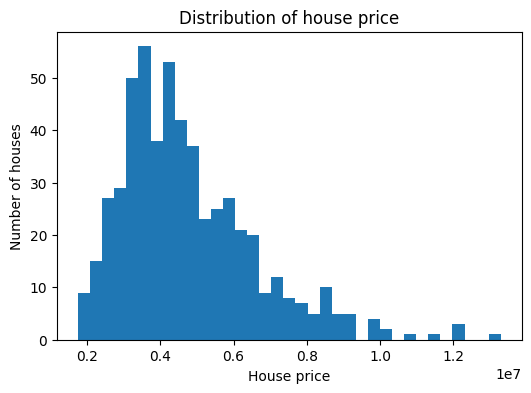

In [16]:
# Price distribution of houses

plt.figure(figsize=(6,4))

plt.hist(df["price"], bins=35)

plt.title("Distribution of house price")

plt.xlabel("House price")

plt.ylabel("Number of houses")

plt.show()

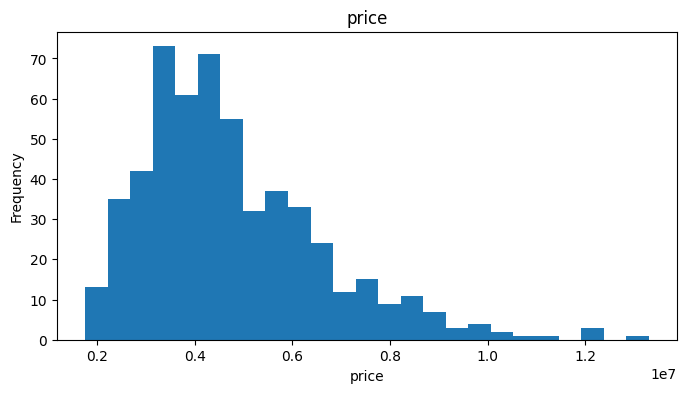

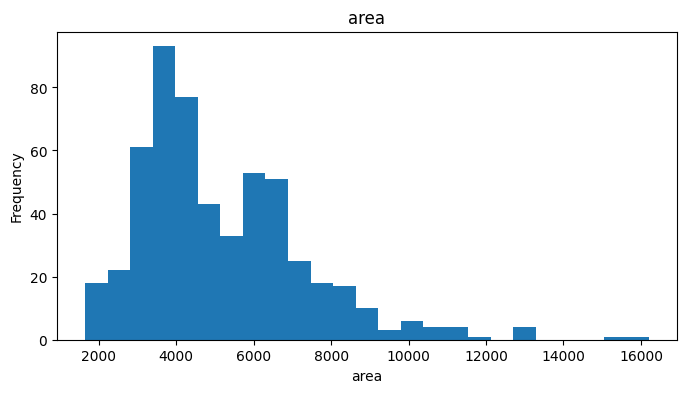

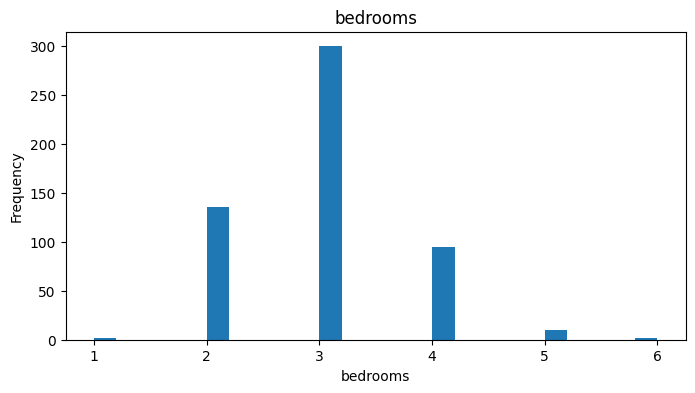

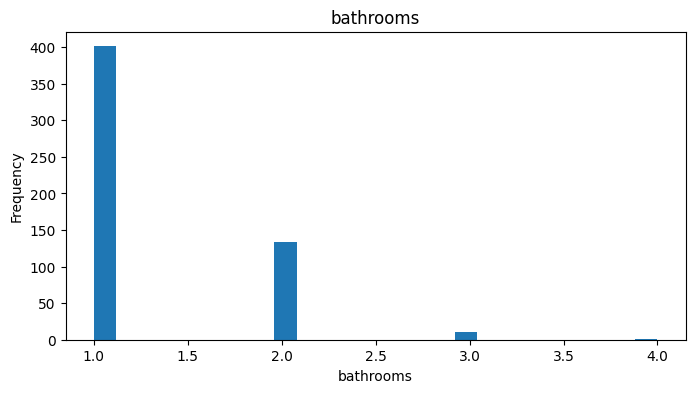

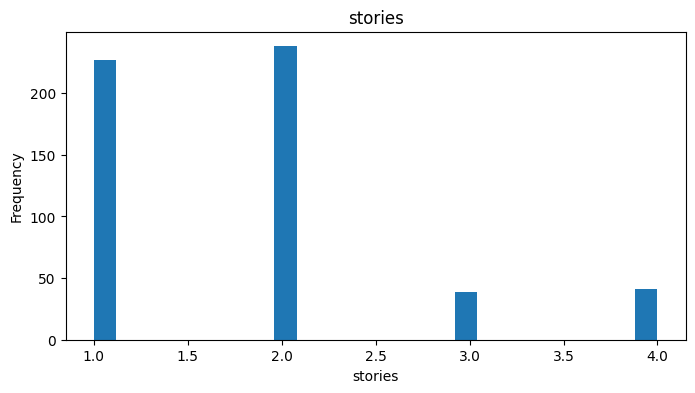

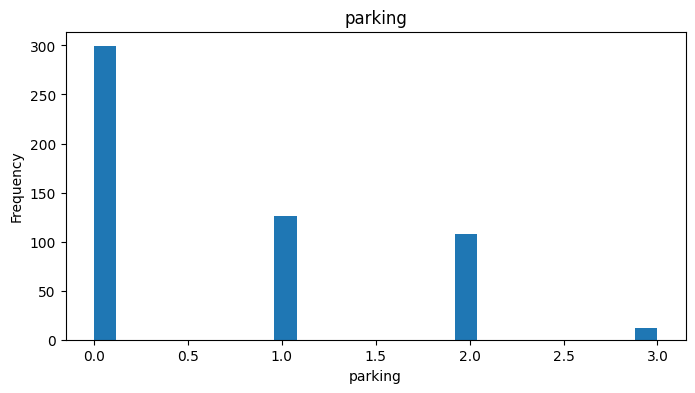

In [17]:
for column in numerical_columns:

    plt.figure(figsize=(8,4))

    plt.hist(df[column], bins=25)

    plt.title(column)

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.show()

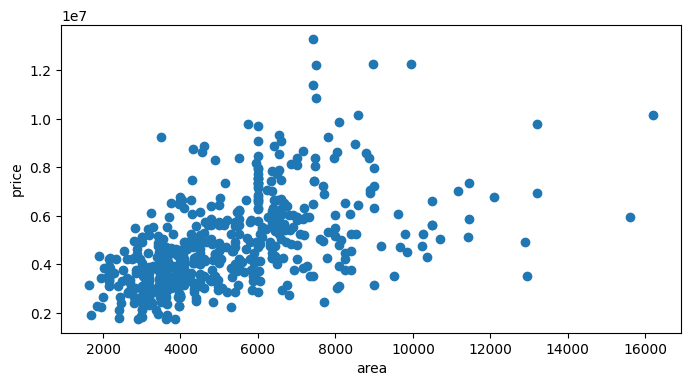

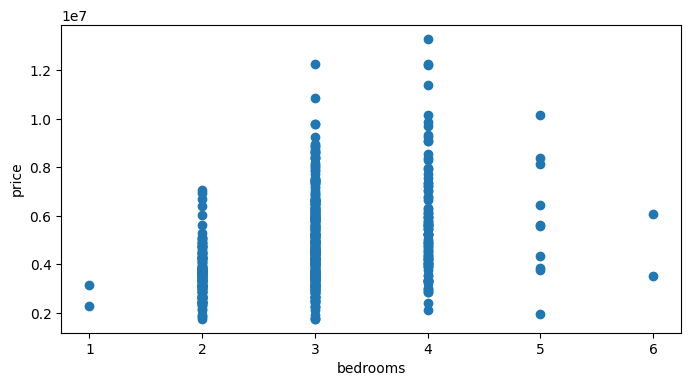

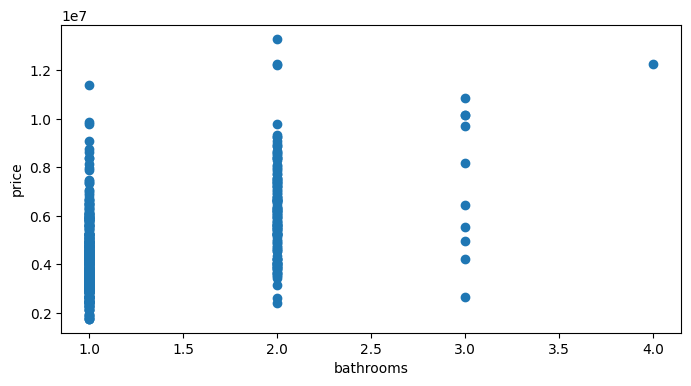

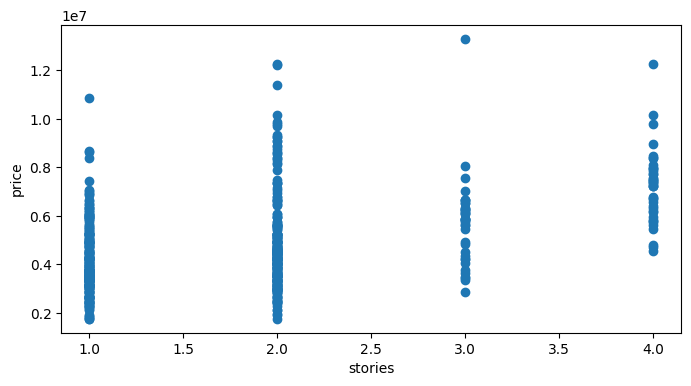

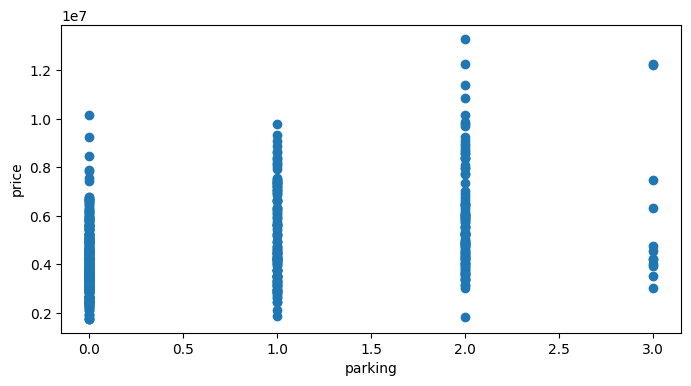

In [18]:
features = numerical_columns
for feature in features[1:]:
    plt.figure(figsize=(8,4))
    plt.scatter(df[feature], df['price'])
    plt.xlabel(feature)
    plt.ylabel("price")
    plt.show()

In [19]:
# Correlation of features with target

price_corr = df[numerical_columns].corr()['price'].sort_values(ascending = False)
print(price_corr)

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64


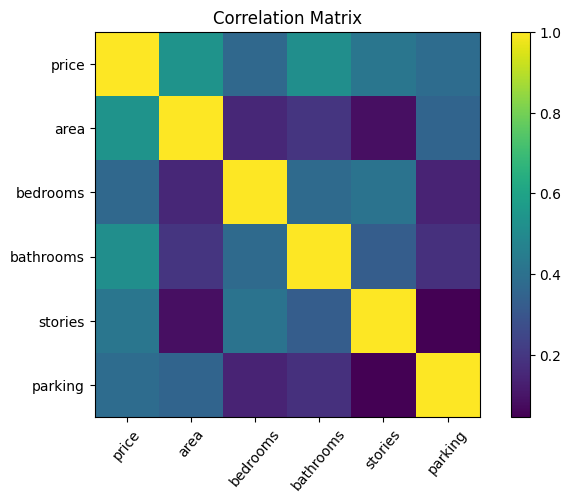

In [20]:
# Correlation
correlation = df[numerical_columns].corr()

# Plot correlation in figure
plt.figure(figsize=(8,5))
plt.imshow(correlation)
plt.colorbar()
plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=50)
plt.yticks(range(len(correlation.columns)),
           correlation.columns)
plt.title("Correlation Matrix")
plt.show()

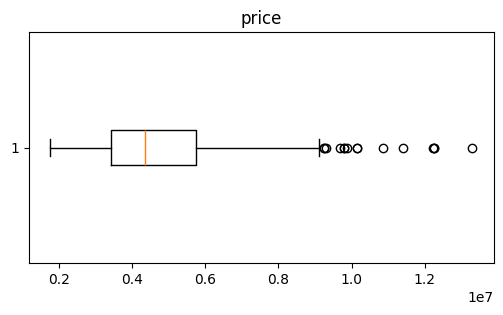

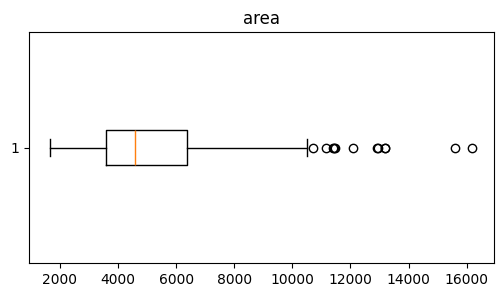

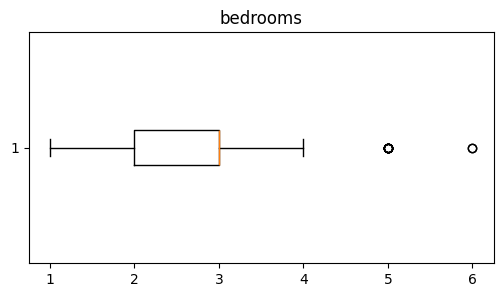

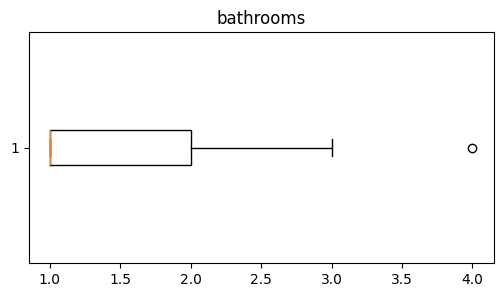

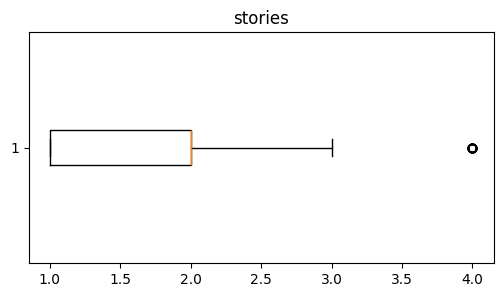

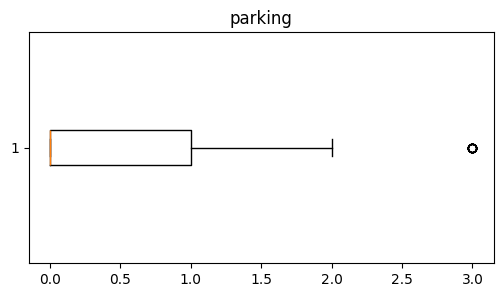

In [21]:
for column in numerical_columns:

    plt.figure(figsize=(6,3))

    plt.boxplot(df[column], vert=False)

    plt.title(column)

    plt.show()

## Data Preprocessing

In [22]:
# Copy the orginal dataset into a new variable

df_processed = df.copy()

# Columns containing yes/no values

mappings = {'mainroad':{'yes':1, 'no':0},
            'guestroom':{'yes':1, 'no':0},
            'basement':{'yes':1, 'no':0},
            'hotwaterheating':{'yes':1, 'no':0},
            'airconditioning':{'yes':1, 'no':0},
            'prefarea':{'yes':1, 'no':0},
            }

for column,mapping in mappings.items():
    df_processed[column] = df_processed[column].map(mapping)
    
# Encode furnishing status column 
df_processed = pd.get_dummies(
    df_processed,
    columns=["furnishingstatus"],
    drop_first=True,
    dtype=int
)

In [23]:
# Rename furnishing_status columns
df_processed.rename(columns={"furnishingstatus_semi-furnished": "semi-furnished", "furnishingstatus_unfurnished": "unfurnished"}, inplace = True)
df_processed.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [24]:
# Seperate features and target column

X = df_processed.drop("price", axis = 1)
Y = df_processed["price"]

print(X.shape)
print(Y.shape)

(545, 13)
(545,)


In [25]:
# Split training and testing data

x_train, x_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size = 0.2,
    random_state = 45
) #----------------------(train_test_split)----->>returns numpy arrays

# Check the shape

print("Training Features :", x_train.shape)
print("Testing Features  :", x_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (436, 13)
Testing Features  : (109, 13)
Training Target   : (436,)
Testing Target    : (109,)


In [26]:
y_test.values

array([ 2520000,  5215000,  2940000,  3850000,  2835000,  7455000,
        4900000,  4193000,  3087000,  2940000,  3675000,  4893000,
        7962500,  6230000,  3500000,  4550000,  2604000,  3710000,
        4515000,  4956000,  3150000,  5215000,  3010000,  3080000,
        1890000,  2380000,  6790000,  3500000,  2450000,  4060000,
        3920000,  3850000,  3850000,  3290000,  6230000,  2100000,
        7035000,  5320000,  4200000,  7000000,  5810000,  3395000,
        4690000,  7070000, 10150000,  5943000,  4515000,  4200000,
        3220000,  3430000,  4200000,  6419000,  3836000,  3290000,
        2660000,  5803000,  5810000,  4270000,  4473000,  3773000,
        3150000,  4445000,  5600000,  5873000,  9681000,  6265000,
        5740000,  4900000,  3290000,  4403000,  6107500, 11410000,
        7420000,  5040000,  3500000,  3010000,  3920000,  3430000,
        5740000,  3115000,  4375000,  5250000,  2275000,  7910000,
        5250000,  5600000,  6650000,  5523000,  2800000,  5600

In [27]:
# Fit and transform traning data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)

# Transform the test data
x_test_scaled = scaler.transform(x_test)

print("First Five Rows of Scaled Training Data:\n")

print(x_train_scaled[:4])

First Five Rows of Scaled Training Data:

[[-0.3903953   0.04013665 -0.58683062 -0.93175525  0.39559913 -0.46312491
  -0.73527957 -0.2413554  -0.69497712 -0.77682839 -0.56322335  1.17028425
  -0.69135093]
 [ 0.00606946  0.04013665 -0.58683062  2.5207543   0.39559913 -0.46312491
  -0.73527957 -0.2413554   1.43889629 -0.77682839 -0.56322335  1.17028425
  -0.69135093]
 [ 0.02039951  0.04013665 -0.58683062  1.36991778  0.39559913 -0.46312491
  -0.73527957 -0.2413554   1.43889629 -0.77682839 -0.56322335  1.17028425
  -0.69135093]
 [ 1.26233731  0.04013665  1.39656589  0.21908126  0.39559913 -0.46312491
  -0.73527957 -0.2413554  -0.69497712 -0.77682839  1.77549457  1.17028425
  -0.69135093]]


## Build and Train the Linear Regression Model

In [28]:
# Create the SGD Regressor

model = SGDRegressor(
    max_iter=1000,
    learning_rate="invscaling",
    eta0=0.01,
    random_state=42
)


# Train the Model

model.fit(x_train_scaled, y_train)


# Check whether training finished

print("Number of iterations:", model.n_iter_)

Number of iterations: 25


In [29]:
# Check the weights and bias

print(f"Weights:\n{model.coef_} ")

print(f"Bias: {model.intercept_}")

Weights:
[ 570048.99770943   74728.34570746  530927.09814799  320707.36031755
  137397.80306064   65731.48613986  191422.35143603  178295.04879162
  444621.74227714  243617.38641135  265554.51320444  -46189.24686469
 -225589.81860305] 
Bias: [4793907.73008683]


In [30]:
#Display Every Feature with Its Weight

feature_weights = pd.DataFrame(
    {
        "features": X.columns,
        "weights" : model.coef_
    }
)

feature_weights


,features,weights
0,area,570048.997709
1,bedrooms,74728.345707
2,bathrooms,530927.098148
3,stories,320707.360318
4,mainroad,137397.803061
5,guestroom,65731.486140
6,basement,191422.351436
7,hotwaterheating,178295.048792
8,airconditioning,444621.742277
9,parking,243617.386411


In [31]:
# Sort feature by importance

feature_weights = feature_weights.sort_values(
    by = "weights",
    ascending = False
)
feature_weights

,features,weights
0,area,570048.997709
2,bathrooms,530927.098148
8,airconditioning,444621.742277
3,stories,320707.360318
10,prefarea,265554.513204
9,parking,243617.386411
6,basement,191422.351436
7,hotwaterheating,178295.048792
4,mainroad,137397.803061
1,bedrooms,74728.345707


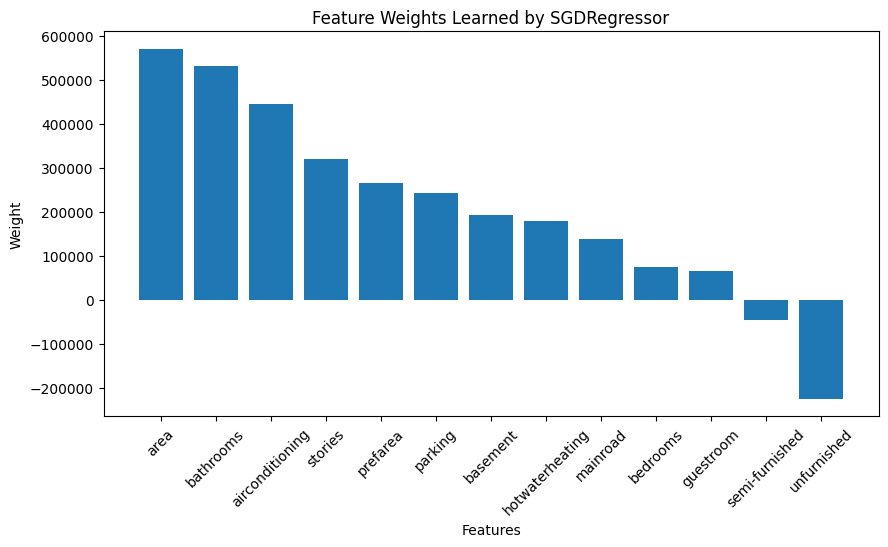

In [32]:
#Visualize feature weights

plt.figure(figsize=(10,5))

plt.bar(feature_weights["features"],
        feature_weights["weights"])

plt.xticks(rotation=45)

plt.title("Feature Weights Learned by SGDRegressor")

plt.xlabel("Features")

plt.ylabel("Weight")

plt.show()

## Predictions & Model Evaluation

In [33]:
# Predict House Prices

y_pred = model.predict(x_test_scaled)

In [34]:
# Compare Actual vs Predicted Values

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,2520000,2.070237e+06
1,5215000,4.935479e+06
2,2940000,2.512838e+06
3,3850000,5.435262e+06
4,2835000,2.672068e+06
5,7455000,4.967285e+06
6,4900000,4.855084e+06
7,4193000,3.670449e+06
8,3087000,4.078201e+06
9,2940000,2.920881e+06


In [35]:
# Calculate MAE
mae       = mean_absolute_error(y_test, y_pred)
# Calculate MSE
mse       = np.mean((y_test - y_pred)**2)
# Calculate RMSE
rmse      = np.sqrt(mse)
# Calculate R-Squared
R_Squared = r2_score(y_test, y_pred)

In [36]:
# Print Everything Together

print('-'*32)

print(f"MAE  : {mae:,.2f}")

print(f"MSE  : {mse:,.2f}")

print(f"RMSE : {rmse:,.2f}")

print(f"R²   : {R_Squared:.4f}")

print('-'*32)

--------------------------------
MAE  : 854,096.73
MSE  : 1,194,650,878,594.41
RMSE : 1,093,000.86
R²   : 0.6002
--------------------------------


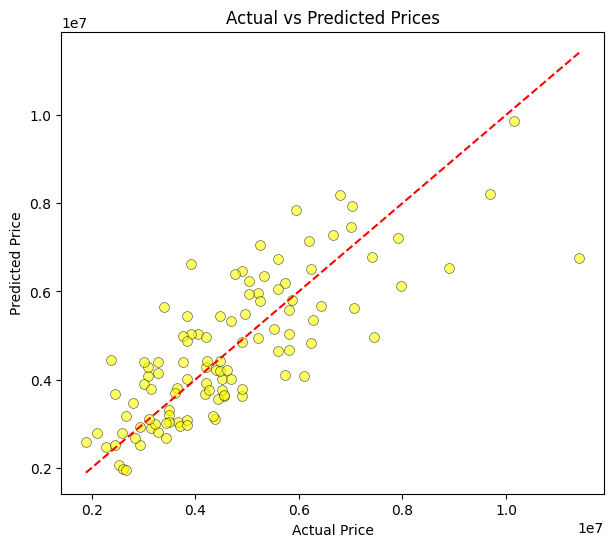

In [37]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, 
            s=50,          # size of dots
            marker='o',    # shape of dots
            c='yellow',      # color
            alpha=0.6,     # transparency (0=invisible, 1=solid)
            edgecolors='black',  # outline color
            linewidths=0.5)      # outline thickness

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

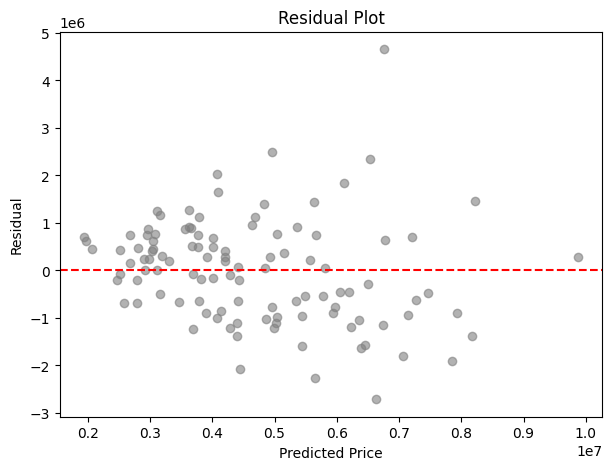

In [38]:
# Residual plot

residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.6, color="grey",)
plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [39]:
# Predict the price of a new house

new_house = pd.DataFrame([{
    "area": 7000,
    "bedrooms": 3,
    "bathrooms": 2,
    "stories": 2,
    "mainroad": 1,
    "guestroom": 0,
    "basement": 1,
    "hotwaterheating": 0,
    "airconditioning": 1,
    "parking": 2,
    "prefarea": 1,
    "semi-furnished": 0,
    "unfurnished": 1
}])

new_house_scaled = scaler.transform(new_house)

predicted_price = model.predict(new_house_scaled)

print(f"Predicted House Price: ${predicted_price[0]:,.1f}")

Predicted House Price: $7,557,813.6
